# 08 — Extract CASIA-B Silhouettes Only

এই notebook raw CASIA-B video থেকে silhouette sequence extract করবে।

Output example:

```text
/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/yolo11m_seg_64x44/001/nm-01/000.npz
```

এই notebook skeleton আবার extract করবে না। Existing skeleton-এর সাথে alignment check করবে notebook `09_validate_silhouette_skeleton_alignment.ipynb`.

In [1]:
# ============================================================
# CELL 1 — Install missing packages only
# ============================================================
import sys, subprocess, importlib.util

def pip_install_if_missing(package_name, import_name=None):
    if import_name is None:
        import_name = package_name
    if importlib.util.find_spec(import_name) is None:
        print(f"[INSTALL] {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(f"[OK] {package_name} already installed")

pip_install_if_missing("ultralytics", "ultralytics")
pip_install_if_missing("opencv-python", "cv2")
pip_install_if_missing("numpy", "numpy")
pip_install_if_missing("pandas", "pandas")
pip_install_if_missing("tqdm", "tqdm")
pip_install_if_missing("matplotlib", "matplotlib")

[OK] ultralytics already installed
[OK] opencv-python already installed
[OK] numpy already installed
[OK] pandas already installed
[OK] tqdm already installed
[OK] matplotlib already installed


In [2]:
# ============================================================
# CELL 2 — Imports, paths, config
# ============================================================
from pathlib import Path
import re, time, gc, traceback, warnings
import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from ultralytics import YOLO

warnings.filterwarnings("ignore")

RAW_DIR = Path("/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/video")
EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")

SEG_MODEL_CANDIDATES = [
    "yolo11m-seg.pt",
    "yolov8m-seg.pt",
    "yolo11s-seg.pt",
    "yolov8s-seg.pt",
    "yolo11n-seg.pt",
    "yolov8n-seg.pt",
]
SEG_MODEL_NAME = SEG_MODEL_CANDIDATES[0]

DEVICE = 0 if torch.cuda.is_available() else "cpu"
IMG_SIZE = 640
DET_CONF = 0.25
IOU = 0.70
MAX_DET = 5
USE_HALF = True

SIL_H = 64
SIL_W = 44
MASK_THRESHOLD = 0.50
MIN_MASK_AREA_RATIO = 0.001

TEST_FIRST_N = 5
RUN_FULL_EXTRACTION = True
SAVE_DEBUG_VIS_N = 80
VIS_STRIDE = 10
OVERWRITE = False

INDEX_DIR = EXP_DIR / "data" / "index"
REPORT_DIR = EXP_DIR / "data" / "reports"
VIS_BASE_DIR = EXP_DIR / "visuals" / "silhouette_debug"

for d in [INDEX_DIR, REPORT_DIR, VIS_BASE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def safe_model_tag(model_name: str, h=SIL_H, w=SIL_W):
    base = Path(model_name).stem.replace("-", "_").replace(".", "_").replace(" ", "_")
    return f"{base}_{h}x{w}"

MODEL_TAG = safe_model_tag(SEG_MODEL_NAME)
SIL_ROOT = EXP_DIR / "data" / "silhouettes" / MODEL_TAG
VIS_DIR = VIS_BASE_DIR / MODEL_TAG
SIL_ROOT.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("CASIA-B Silhouette Extraction")
print("=" * 80)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("RAW_DIR:", RAW_DIR)
print("EXP_DIR:", EXP_DIR)
print("Initial model:", SEG_MODEL_NAME)
print("SIL_ROOT:", SIL_ROOT)
print("Device:", DEVICE)
print("Output size:", f"{SIL_H}x{SIL_W}")
print("=" * 80)

CASIA-B Silhouette Extraction
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
RAW_DIR: /media/wadud/DriveUbuntu/CASIA/Main/DatasetB/video
EXP_DIR: /media/wadud/DriveUbuntu/GaitRecognition 2.0
Initial model: yolo11m-seg.pt
SIL_ROOT: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/yolo11m_seg_64x44
Device: 0
Output size: 64x44


In [3]:
# ============================================================
# CELL 3 — Discover CASIA-B videos
# ============================================================
VIDEO_RE = re.compile(
    r"^(?P<subject>\d{3})-(?P<condition>nm|bg|cl)-(?P<seq>\d{2})-(?P<view>\d{3})\.(?P<ext>avi|mp4|mov|mkv)$",
    re.IGNORECASE
)
VIDEO_EXTS = {".avi", ".mp4", ".mov", ".mkv"}

def parse_casiab_filename(path: Path):
    match = VIDEO_RE.match(path.name)
    if match is None:
        return None
    gd = match.groupdict()
    return {
        "video_path": str(path),
        "filename": path.name,
        "subject": gd["subject"],
        "condition": gd["condition"].lower(),
        "seq": gd["seq"],
        "view": gd["view"],
    }

def discover_videos(raw_dir: Path):
    if not raw_dir.exists():
        raise FileNotFoundError(f"Raw video directory not found: {raw_dir}")
    records, skipped = [], []
    video_paths = sorted([p for p in raw_dir.rglob("*") if p.is_file() and p.suffix.lower() in VIDEO_EXTS])
    for p in video_paths:
        rec = parse_casiab_filename(p)
        if rec is None:
            skipped.append({"video_path": str(p), "reason": "filename_pattern_not_matched"})
        else:
            records.append(rec)
    return records, skipped

records, skipped = discover_videos(RAW_DIR)
df_index = pd.DataFrame(records)
df_skipped = pd.DataFrame(skipped)

index_csv = INDEX_DIR / "casiab_video_index_for_silhouette.csv"
skipped_csv = REPORT_DIR / "silhouette_skipped_filenames.csv"
df_index.to_csv(index_csv, index=False)
df_skipped.to_csv(skipped_csv, index=False)

print("Matched videos:", len(records))
print("Skipped names :", len(skipped))
print("Expected      :", 124 * 10 * 11)
display(df_index.head())

Matched videos: 13640
Skipped names : 1364
Expected      : 13640


,video_path,filename,subject,condition,seq,view
0,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,001-bg-01-000.avi,001,bg,01,000
1,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,001-bg-01-018.avi,001,bg,01,018
2,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,001-bg-01-036.avi,001,bg,01,036
3,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,001-bg-01-054.avi,001,bg,01,054
4,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,001-bg-01-072.avi,001,bg,01,072


In [4]:
# ============================================================
# CELL 4 — Load segmentation model with fallback
# ============================================================
def load_seg_model_with_fallback(model_candidates):
    errors = []
    for model_name in model_candidates:
        print("Trying:", model_name)
        try:
            model = YOLO(model_name)
            print("[OK] Loaded:", model_name)
            return model, model_name
        except Exception as e:
            errors.append((model_name, str(e)))
            print("[FAILED]", model_name, e)
    print("All model candidates failed:")
    for name, err in errors:
        print(name, err)
    raise RuntimeError("Could not load any Ultralytics segmentation model.")

seg_model, SEG_MODEL_NAME = load_seg_model_with_fallback(SEG_MODEL_CANDIDATES)
MODEL_TAG = safe_model_tag(SEG_MODEL_NAME)
SIL_ROOT = EXP_DIR / "data" / "silhouettes" / MODEL_TAG
VIS_DIR = VIS_BASE_DIR / MODEL_TAG
SIL_ROOT.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)

print("Final model:", SEG_MODEL_NAME)
print("SIL_ROOT:", SIL_ROOT)
print("VIS_DIR:", VIS_DIR)

Trying: yolo11m-seg.pt
[OK] Loaded: yolo11m-seg.pt
Final model: yolo11m-seg.pt
SIL_ROOT: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/yolo11m_seg_64x44
VIS_DIR: /media/wadud/DriveUbuntu/GaitRecognition 2.0/visuals/silhouette_debug/yolo11m_seg_64x44


In [5]:
# ============================================================
# CELL 5 — Helper functions
# ============================================================
def get_video_meta(video_path: Path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {"readable": False, "fps": 0.0, "width": 0, "height": 0, "frame_count_cv2": 0}
    fps = float(cap.get(cv2.CAP_PROP_FPS) or 0.0)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    cap.release()
    return {"readable": True, "fps": fps, "width": width, "height": height, "frame_count_cv2": frame_count}

def to_numpy(x):
    if x is None:
        return None
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    if hasattr(x, "cpu"):
        return x.cpu().numpy()
    return np.asarray(x)

def output_npz_path_for_record(record):
    return SIL_ROOT / record["subject"] / f"{record['condition']}-{record['seq']}" / f"{record['view']}.npz"

def output_vis_path_for_record(record):
    return VIS_DIR / f"{record['subject']}-{record['condition']}-{record['seq']}-{record['view']}.jpg"

def clean_binary_mask(mask):
    mask = mask.astype(np.uint8)
    kernel_small = np.ones((3, 3), np.uint8)
    kernel_big = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_small)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_big)
    return mask

def standardize_silhouette(mask, out_h=64, out_w=44):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return np.zeros((out_h, out_w), dtype=np.uint8), False, [np.nan, np.nan, np.nan, np.nan]

    x1, x2 = int(xs.min()), int(xs.max()) + 1
    y1, y2 = int(ys.min()), int(ys.max()) + 1
    crop = mask[y1:y2, x1:x2]

    h, w = crop.shape[:2]
    if h <= 0 or w <= 0:
        return np.zeros((out_h, out_w), dtype=np.uint8), False, [np.nan, np.nan, np.nan, np.nan]

    new_w = max(1, int(round(w * (out_h / float(h)))))
    resized = cv2.resize(crop, (new_w, out_h), interpolation=cv2.INTER_NEAREST)

    if new_w > out_w:
        start = max(0, (new_w - out_w) // 2)
        resized = resized[:, start:start + out_w]
    elif new_w < out_w:
        canvas = np.zeros((out_h, out_w), dtype=np.uint8)
        start = (out_w - new_w) // 2
        canvas[:, start:start + new_w] = resized
        resized = canvas

    sil = (resized > 0).astype(np.uint8) * 255
    return sil, True, [x1, y1, x2, y2]

def extract_person_mask_from_result(result):
    orig_img = getattr(result, "orig_img", None)
    if orig_img is None:
        return None, 0.0, [np.nan, np.nan, np.nan, np.nan], 0.0

    img_h, img_w = orig_img.shape[:2]
    masks_obj = getattr(result, "masks", None)
    boxes_obj = getattr(result, "boxes", None)

    if masks_obj is None or getattr(masks_obj, "data", None) is None:
        return None, 0.0, [np.nan, np.nan, np.nan, np.nan], 0.0

    masks_data = to_numpy(masks_obj.data)
    if masks_data is None or masks_data.size == 0:
        return None, 0.0, [np.nan, np.nan, np.nan, np.nan], 0.0

    n = masks_data.shape[0]
    cls = to_numpy(boxes_obj.cls).astype(np.int64) if boxes_obj is not None and getattr(boxes_obj, "cls", None) is not None else np.zeros((n,), dtype=np.int64)
    conf = to_numpy(boxes_obj.conf).astype(np.float32) if boxes_obj is not None and getattr(boxes_obj, "conf", None) is not None else np.ones((n,), dtype=np.float32)
    boxes = to_numpy(boxes_obj.xyxy).astype(np.float32) if boxes_obj is not None and getattr(boxes_obj, "xyxy", None) is not None else np.full((n, 4), np.nan, dtype=np.float32)

    best_idx, best_score = None, -1.0

    for i in range(n):
        if int(cls[i]) != 0:
            continue

        mask_i = masks_data[i].astype(np.float32)
        mask_i = cv2.resize(mask_i, (img_w, img_h), interpolation=cv2.INTER_LINEAR)
        binary = (mask_i >= MASK_THRESHOLD).astype(np.uint8)

        area = float(binary.sum())
        area_ratio = area / max(float(img_w * img_h), 1.0)
        if area_ratio < MIN_MASK_AREA_RATIO:
            continue

        score = float(conf[i]) + 0.25 * area_ratio
        if score > best_score:
            best_score = score
            best_idx = i
            best_binary = binary
            best_conf = float(conf[i])
            best_box = boxes[i].tolist() if i < len(boxes) else [np.nan, np.nan, np.nan, np.nan]
            best_area = area

    if best_idx is None:
        return None, 0.0, [np.nan, np.nan, np.nan, np.nan], 0.0

    best_binary = clean_binary_mask(best_binary)
    return best_binary, best_conf, best_box, best_area

def make_debug_sheet(frames):
    if len(frames) == 0:
        return None
    thumbs = []
    for frame in frames:
        h, w = frame.shape[:2]
        new_w = 160
        new_h = max(1, int(round(h * new_w / float(max(w, 1)))))
        thumbs.append(cv2.resize(frame, (new_w, new_h), interpolation=cv2.INTER_AREA))
    max_h = max(t.shape[0] for t in thumbs)
    padded = []
    for t in thumbs:
        h, w = t.shape[:2]
        if h < max_h:
            t = np.vstack([t, np.zeros((max_h - h, w, 3), dtype=t.dtype)])
        padded.append(t)
    return np.hstack(padded)

def make_debug_frame(orig_img, mask, sil_small, label):
    img = orig_img.copy()
    if mask is not None:
        colored = np.zeros_like(img)
        colored[:, :, 1] = (mask * 255).astype(np.uint8)
        img = cv2.addWeighted(img, 0.65, colored, 0.35, 0)

    cv2.putText(img, label, (8, 18), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

    sil_rgb = cv2.cvtColor(sil_small, cv2.COLOR_GRAY2BGR)
    sil_rgb = cv2.resize(sil_rgb, (44 * 3, 64 * 3), interpolation=cv2.INTER_NEAREST)

    h1, w1 = img.shape[:2]
    h2, w2 = sil_rgb.shape[:2]
    if h2 > h1:
        sil_rgb = cv2.resize(sil_rgb, (w2, h1), interpolation=cv2.INTER_NEAREST)
        h2, w2 = sil_rgb.shape[:2]

    canvas = np.zeros((h1, w1 + w2, 3), dtype=np.uint8)
    canvas[:, :w1] = img
    canvas[:h2, w1:w1+w2] = sil_rgb
    return canvas

In [6]:
# ============================================================
# CELL 6 — Process one video
# ============================================================
def process_one_video(record, save_vis=False):
    video_path = Path(record["video_path"])
    out_npz = output_npz_path_for_record(record)

    if out_npz.exists() and not OVERWRITE:
        return {
            "status": "skipped_exists", "video_path": str(video_path), "out_npz": str(out_npz),
            "subject": record["subject"], "condition": record["condition"], "seq": record["seq"], "view": record["view"],
            "fps": "", "width": "", "height": "", "frame_count_cv2": "", "frame_count_processed": "",
            "valid_frame_ratio": "", "mean_det_score": "", "mean_mask_area": "", "error": "",
        }

    meta = get_video_meta(video_path)
    if not meta["readable"]:
        raise RuntimeError(f"OpenCV cannot read video: {video_path}")

    pred_kwargs = {
        "source": str(video_path), "stream": True, "verbose": False,
        "conf": DET_CONF, "iou": IOU, "imgsz": IMG_SIZE, "max_det": MAX_DET, "device": DEVICE,
    }
    if USE_HALF and DEVICE != "cpu":
        pred_kwargs["half"] = True

    silhouettes, frame_valid, det_scores, mask_areas = [], [], [], []
    raw_bboxes, crop_bboxes, frame_indices = [], [], []
    debug_frames = []

    width, height = meta["width"], meta["height"]
    frame_idx = 0

    for result in seg_model.predict(**pred_kwargs):
        orig_img = getattr(result, "orig_img", None)
        if orig_img is not None:
            h, w = orig_img.shape[:2]
            width = width or w
            height = height or h

        mask, det_conf, raw_box, mask_area = extract_person_mask_from_result(result)

        if mask is None:
            sil = np.zeros((SIL_H, SIL_W), dtype=np.uint8)
            valid = False
            crop_box = [np.nan, np.nan, np.nan, np.nan]
        else:
            sil, valid, crop_box = standardize_silhouette(mask, SIL_H, SIL_W)

        silhouettes.append(sil)
        frame_valid.append(bool(valid))
        det_scores.append(float(det_conf))
        mask_areas.append(float(mask_area))
        raw_bboxes.append(raw_box)
        crop_bboxes.append(crop_box)
        frame_indices.append(int(frame_idx))

        if save_vis and orig_img is not None and frame_idx % VIS_STRIDE == 0 and len(debug_frames) < 8:
            label = f"{record['subject']}-{record['condition']}-{record['seq']}-{record['view']} f={frame_idx}"
            debug_frames.append(make_debug_frame(orig_img, mask, sil, label))

        frame_idx += 1

    if len(silhouettes) == 0:
        raise RuntimeError(f"No frames processed by segmentation model: {video_path}")

    silhouettes = np.stack(silhouettes, axis=0).astype(np.uint8)
    frame_valid = np.asarray(frame_valid, dtype=np.bool_)
    det_scores = np.asarray(det_scores, dtype=np.float32)
    mask_areas = np.asarray(mask_areas, dtype=np.float32)
    raw_bboxes = np.asarray(raw_bboxes, dtype=np.float32)
    crop_bboxes = np.asarray(crop_bboxes, dtype=np.float32)
    frame_indices = np.asarray(frame_indices, dtype=np.int32)

    out_npz.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        out_npz,
        silhouettes=silhouettes, frame_valid=frame_valid, det_scores=det_scores,
        mask_areas=mask_areas, raw_bboxes=raw_bboxes, crop_bboxes=crop_bboxes, frame_indices=frame_indices,
        subject=np.array(record["subject"]), condition=np.array(record["condition"]),
        seq=np.array(record["seq"]), view=np.array(record["view"]),
        video_path=np.array(str(video_path)), filename=np.array(record["filename"]),
        seg_model=np.array(SEG_MODEL_NAME), model_tag=np.array(MODEL_TAG),
        fps=np.array(meta["fps"], dtype=np.float32), width=np.array(width, dtype=np.int32), height=np.array(height, dtype=np.int32),
        frame_count_cv2=np.array(meta["frame_count_cv2"], dtype=np.int32),
        frame_count_processed=np.array(len(silhouettes), dtype=np.int32),
        silhouette_height=np.array(SIL_H, dtype=np.int32), silhouette_width=np.array(SIL_W, dtype=np.int32),
    )

    if save_vis and len(debug_frames) > 0:
        sheet = make_debug_sheet(debug_frames)
        if sheet is not None:
            cv2.imwrite(str(output_vis_path_for_record(record)), sheet)

    valid_frame_ratio = float(frame_valid.mean()) if len(frame_valid) else 0.0
    mean_det_score = float(np.nanmean(det_scores)) if det_scores.size else 0.0
    mean_mask_area = float(np.nanmean(mask_areas)) if mask_areas.size else 0.0

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "status": "ok", "video_path": str(video_path), "out_npz": str(out_npz),
        "subject": record["subject"], "condition": record["condition"], "seq": record["seq"], "view": record["view"],
        "fps": meta["fps"], "width": width, "height": height, "frame_count_cv2": meta["frame_count_cv2"],
        "frame_count_processed": len(silhouettes), "valid_frame_ratio": valid_frame_ratio,
        "mean_det_score": mean_det_score, "mean_mask_area": mean_mask_area, "error": "",
    }

In [7]:
# ============================================================
# CELL 7 — Test extraction on first few videos
# ============================================================
if len(records) == 0:
    raise RuntimeError("No CASIA-B videos found.")

test_summary = []

for rec in tqdm(records[:TEST_FIRST_N], desc=f"Testing first {TEST_FIRST_N} videos"):
    try:
        test_summary.append(process_one_video(rec, save_vis=True))
    except Exception as e:
        test_summary.append({
            "status": "failed", "video_path": rec["video_path"], "out_npz": str(output_npz_path_for_record(rec)),
            "subject": rec["subject"], "condition": rec["condition"], "seq": rec["seq"], "view": rec["view"],
            "fps": "", "width": "", "height": "", "frame_count_cv2": "", "frame_count_processed": "",
            "valid_frame_ratio": "", "mean_det_score": "", "mean_mask_area": "", "error": str(e),
        })
        print("FAILED:", rec["video_path"])
        print(traceback.format_exc())

df_test = pd.DataFrame(test_summary)
display(df_test)
print("Debug visuals:", VIS_DIR)

Testing first 5 videos:   0%|          | 0/5 [00:00<?, ?it/s]

,status,video_path,out_npz,subject,condition,seq,view,fps,width,height,frame_count_cv2,frame_count_processed,valid_frame_ratio,mean_det_score,mean_mask_area,error
0,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,000,25.0,320,240,99,99,1.000000,0.910541,4039.515137,
1,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,018,25.0,320,240,102,102,1.000000,0.905187,4417.048828,
2,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,036,25.0,320,240,99,99,0.969697,0.862985,3496.373779,
3,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,054,25.0,320,240,106,106,0.943396,0.839839,2664.773682,
4,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,072,25.0,320,240,106,106,0.811321,0.682147,2239.179199,


Debug visuals: /media/wadud/DriveUbuntu/GaitRecognition 2.0/visuals/silhouette_debug/yolo11m_seg_64x44


Debug images: 5


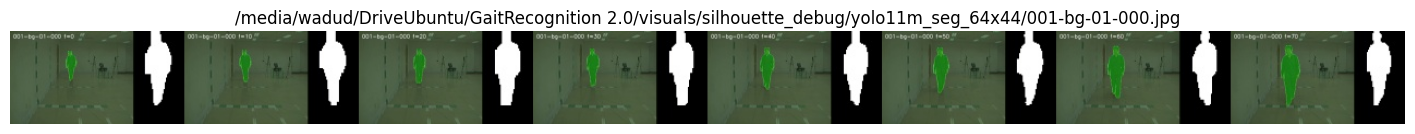

In [8]:
# ============================================================
# CELL 8 — Display one debug image
# ============================================================
debug_images = sorted(VIS_DIR.glob("*.jpg"))
print("Debug images:", len(debug_images))

if debug_images:
    img = cv2.imread(str(debug_images[0]))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(18, 5))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(str(debug_images[0]))
    plt.show()
else:
    print("No debug image found yet.")

In [9]:
# ============================================================
# CELL 9 — Full silhouette extraction
# ============================================================
summary_rows, failed_rows = [], []

if RUN_FULL_EXTRACTION:
    start_time = time.time()

    for idx, rec in enumerate(tqdm(records, desc="Extracting all CASIA-B silhouettes")):
        try:
            summary_rows.append(process_one_video(rec, save_vis=(idx < SAVE_DEBUG_VIS_N)))
        except Exception as e:
            err = traceback.format_exc()
            summary_rows.append({
                "status": "failed", "video_path": rec["video_path"], "out_npz": str(output_npz_path_for_record(rec)),
                "subject": rec["subject"], "condition": rec["condition"], "seq": rec["seq"], "view": rec["view"],
                "fps": "", "width": "", "height": "", "frame_count_cv2": "", "frame_count_processed": "",
                "valid_frame_ratio": "", "mean_det_score": "", "mean_mask_area": "", "error": str(e),
            })
            failed_rows.append({"video_path": rec["video_path"], "error": err})

        if len(summary_rows) % 100 == 0:
            pd.DataFrame(summary_rows).to_csv(REPORT_DIR / "silhouette_extraction_summary_partial.csv", index=False)

    df_summary = pd.DataFrame(summary_rows)
    df_failed = pd.DataFrame(failed_rows)

    summary_csv = REPORT_DIR / "silhouette_extraction_summary.csv"
    failed_csv = REPORT_DIR / "silhouette_failed_videos.csv"
    df_summary.to_csv(summary_csv, index=False)
    df_failed.to_csv(failed_csv, index=False)

    print("=" * 80)
    print("FULL SILHOUETTE EXTRACTION DONE")
    print("Elapsed minutes:", (time.time() - start_time) / 60)
    print("Summary:", summary_csv)
    print("Failed :", failed_csv)
    print("Root   :", SIL_ROOT)
    print("=" * 80)
    display(df_summary["status"].value_counts())
else:
    print("RUN_FULL_EXTRACTION=False")

Extracting all CASIA-B silhouettes:   0%|          | 0/13640 [00:00<?, ?it/s]

FULL SILHOUETTE EXTRACTION DONE
Elapsed minutes: 394.28114798069
Summary: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/silhouette_extraction_summary.csv
Failed : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/silhouette_failed_videos.csv
Root   : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/yolo11m_seg_64x44


status
ok                13635
skipped_exists        5
Name: count, dtype: int64

In [10]:
# ============================================================
# CELL 10 — Verify outputs
# ============================================================
sil_files = sorted(SIL_ROOT.rglob("*.npz"))

print("Total silhouette .npz files:", len(sil_files))
print("Expected:", 124 * 10 * 11)
print("Root:", SIL_ROOT)

summary_csv = REPORT_DIR / "silhouette_extraction_summary.csv"

if summary_csv.exists():
    df_summary = pd.read_csv(summary_csv)
    display(df_summary["status"].value_counts())

    ok_df = df_summary[df_summary["status"] == "ok"].copy()
    if len(ok_df) > 0:
        display(ok_df[["frame_count_processed", "valid_frame_ratio", "mean_det_score", "mean_mask_area"]].describe())

        low_quality = ok_df[(ok_df["valid_frame_ratio"] < 0.70) | (ok_df["mean_det_score"] < 0.25)].copy()
        low_quality_csv = REPORT_DIR / "low_quality_silhouette_files.csv"
        low_quality.to_csv(low_quality_csv, index=False)
        print("Low-quality videos:", len(low_quality))
        print("Saved:", low_quality_csv)
        display(low_quality.head(20))

Total silhouette .npz files: 13640
Expected: 13640
Root: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/yolo11m_seg_64x44


status
ok                13635
skipped_exists        5
Name: count, dtype: int64

,frame_count_processed,valid_frame_ratio,mean_det_score,mean_mask_area
count,13635.000000,13635.000000,13635.000000,13635.000000
mean,120.980785,0.848469,0.758719,3418.432442
std,21.730100,0.144996,0.136947,1949.426523
min,12.000000,0.000000,0.000000,0.000000
25%,106.000000,0.722689,0.639255,2234.552368
50%,120.000000,0.877049,0.779452,2835.088135
75%,134.000000,1.000000,0.899448,3966.183350
max,311.000000,1.000000,0.939616,26427.654297


Low-quality videos: 2723
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/low_quality_silhouette_files.csv


,status,video_path,out_npz,subject,condition,seq,view,fps,width,height,frame_count_cv2,frame_count_processed,valid_frame_ratio,mean_det_score,mean_mask_area,error
16,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,bg,2,90,25.0,320.0,240.0,114.0,114.0,0.684211,0.601550,2014.210571,NaN
17,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,bg,2,108,25.0,320.0,240.0,116.0,116.0,0.689655,0.599980,2037.974121,NaN
27,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,cl,1,90,25.0,320.0,240.0,100.0,100.0,0.680000,0.608022,2470.639893,NaN
28,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,cl,1,108,25.0,320.0,240.0,98.0,98.0,0.683673,0.611632,2478.183594,NaN
30,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,cl,1,144,25.0,320.0,240.0,102.0,102.0,0.686275,0.617585,3041.137207,NaN
49,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,nm,1,90,25.0,320.0,240.0,106.0,106.0,0.660377,0.594593,2275.339600,NaN
50,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,nm,1,108,25.0,320.0,240.0,104.0,104.0,0.663462,0.596849,2280.769287,NaN
52,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,nm,1,144,25.0,320.0,240.0,104.0,104.0,0.682692,0.617479,2816.836426,NaN
59,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,nm,2,72,25.0,320.0,240.0,117.0,117.0,0.649573,0.576798,2041.025635,NaN
60,ok,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,nm,2,90,25.0,320.0,240.0,116.0,116.0,0.629310,0.552825,1991.560303,NaN


Sample: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/yolo11m_seg_64x44/001/bg-01/000.npz
Keys: ['silhouettes', 'frame_valid', 'det_scores', 'mask_areas', 'raw_bboxes', 'crop_bboxes', 'frame_indices', 'subject', 'condition', 'seq', 'view', 'video_path', 'filename', 'seg_model', 'model_tag', 'fps', 'width', 'height', 'frame_count_cv2', 'frame_count_processed', 'silhouette_height', 'silhouette_width']
silhouettes: (99, 64, 44)
frame_valid: (99,)


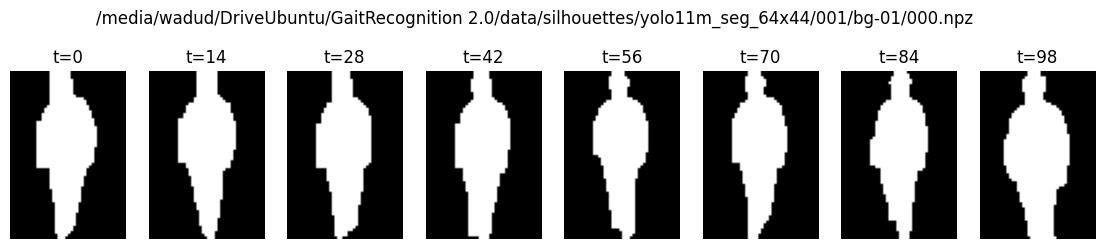

In [11]:
# ============================================================
# CELL 11 — Inspect one saved file
# ============================================================
sil_files = sorted(SIL_ROOT.rglob("*.npz"))

if not sil_files:
    print("No silhouette files found.")
else:
    p = sil_files[0]
    data = np.load(p)
    print("Sample:", p)
    print("Keys:", data.files)
    print("silhouettes:", data["silhouettes"].shape)
    print("frame_valid:", data["frame_valid"].shape)

    S = data["silhouettes"]
    ids = np.linspace(0, len(S)-1, num=min(8, len(S))).astype(int)

    plt.figure(figsize=(14, 3))
    for i, t in enumerate(ids):
        plt.subplot(1, len(ids), i+1)
        plt.imshow(S[t], cmap="gray")
        plt.title(f"t={t}")
        plt.axis("off")
    plt.suptitle(str(p))
    plt.show()

# Last Check

In [12]:
from pathlib import Path

SIL_ROOT = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/yolo11m_seg_64x44")
sil_files = sorted(SIL_ROOT.rglob("*.npz"))

print("Total YOLO silhouette files:", len(sil_files))
print("Expected:", 13640)

Total YOLO silhouette files: 13640
Expected: 13640
